# 3. Explain an ONNX model with DiDAE, without training anything

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Explainable-AI-Berlin/pytorch_explain_and_adapt_library/blob/master/notebooks/03_explain_an_onnx_model_with_didae.ipynb)

Notebook 02 ended with an ONNX classifier and a two-class image folder that fit together. Here DiDAE
asks the model which **concepts** change its decision. Nothing is trained: DiDAE reuses a pretrained
generator (the ImageNet RAE over CLIP) and a pretrained sparse dictionary (MSAE, 6144 named CLIP
concepts), distils your model into CLIP space in closed form, edits along the dictionary concepts,
renders the edits and asks your model again. The model is only ever called forward, so an ONNX file
is enough.

Your model's encoder and the generator's encoder need not be the same network: here a ResNet-18 is
explained through CLIP, in notebook 00 a DINOv3 probe.

**Runtime.** About 15 minutes on one GPU after the downloads (generator weights 6.6 GB, CLIP, the
dictionary). On a GPU under 20 GB (Colab's free T4) it edits a smaller pool of images by itself. Run notebook 02 first, or point the paths below at your own model and data.


## 0. Setup


In [1]:
# Setup: the same cell in every PEAL notebook. Works on Google Colab and locally.
# Colab: Runtime -> Change runtime type -> a GPU. The first run installs PEAL and
# restarts the runtime once (PEAL needs numpy < 2); then run this cell again.
import importlib.util, logging, os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
PEAL_VERSION = "0.1.0"
PEAL_REPO = "https://github.com/Explainable-AI-Berlin/pytorch_explain_and_adapt_library.git"

if importlib.util.find_spec("peal") is None:
    # --ignore-requires-python: PEAL 0.1.0 declares Python < 3.12, Colab runs 3.12
    # (it works there). OpenAI's `clip` package is not on PyPI; the RAE generator needs it.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--ignore-requires-python",
                    f"peal-xai[rae,onnx]=={PEAL_VERSION}", "git+https://github.com/openai/CLIP.git"],
                   check=True)
    if IN_COLAB:
        print("PEAL installed. Restarting the runtime once; run this cell again afterwards.")
        os.kill(os.getpid(), 9)


def find_configs():
    """PEAL's config files live in its repository, not in the pip package.
    Use $PEAL_BASE, else the repository this notebook sits in, else a sparse clone
    (configs/ and the dictionary vocabulary only)."""
    if os.environ.get("PEAL_BASE"):
        return Path(os.environ["PEAL_BASE"])
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "configs" / "web_demo").is_dir():
            return parent
    target = Path("/content/peal" if IN_COLAB else Path.home() / "peal_configs")
    if not (target / "configs").is_dir():
        subprocess.run(["git", "clone", "-q", "--depth", "1", "--filter=blob:none", "--sparse",
                        PEAL_REPO, str(target)], check=True)
        subprocess.run(["git", "-C", str(target), "sparse-checkout", "set", "configs",
                        "peal/dependencies/MSAE/vocab"], check=True)
    return target


os.environ["PEAL_BASE"] = str(find_configs())            # <PEAL_BASE> in config files
CONFIGS = Path(os.environ["PEAL_BASE"]) / "configs"
ROOT = Path("/content/peal_data") if IN_COLAB else Path.home() / "peal_data"
os.environ.setdefault("PEAL_DATA", str(ROOT / "datasets"))  # $PEAL_DATA: datasets
os.environ.setdefault("PEAL_RUNS", str(ROOT / "runs"))      # $PEAL_RUNS: models and runs
os.environ.setdefault("PEAL_RAE_WEIGHTS", "hf://sidney1505/peal-rae-clip-imagenet@v0.1.0")
DATA, RUNS = Path(os.environ["PEAL_DATA"]), Path(os.environ["PEAL_RUNS"])

import warnings
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")      # TensorFlow (pulled in by a dependency) is chatty
warnings.filterwarnings("ignore", message="To copy construct from a tensor")       # PEAL 0.1.0 dataset noise
warnings.filterwarnings("ignore", message='Field "model_', category=UserWarning)   # pydantic namespace notes
logging.getLogger("matplotlib.image").setLevel(logging.ERROR)                      # "Clipping input data" notes

import peal, shutil, torch
# PEAL 0.1.0's wheel misses the concept vocabulary of the MSAE dictionary; copy it in from the repo
from peal.sparse_dictionaries.msae_decomposition import MSAE_DIR
_vocab = Path(MSAE_DIR) / "vocab" / "clip_disect_20k.txt"
if not _vocab.exists():
    _vocab.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(Path(os.environ["PEAL_BASE"]) / "peal/dependencies/MSAE/vocab/clip_disect_20k.txt", _vocab)
from peal.log import configure
configure()   # PEAL logs progress at INFO; drop only its "Loading config ..." dumps and file lists
_quiet = lambda r: not str(r.getMessage()).startswith(
    ("Loading config", "Config model", "No config model", "Saved collage", "[DiDAE Sweep] decoded "))
for _h in logging.getLogger("peal").handlers:
    _h.addFilter(_quiet)
print(f"PEAL {peal.__version__} | configs: {CONFIGS}")
print(f"PEAL_DATA: {DATA} | PEAL_RUNS: {RUNS}")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (this will be very slow)")

# ---- notebook-specific -------------------------------------------------------------------
import io, json, re, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image as PNG

WORK = RUNS / "onnx_didae"
REUSE = True
DEVICE = "cuda"
GPU_GB = torch.cuda.get_device_properties(0).total_memory / 2**30 if torch.cuda.is_available() else 0
SMALL_GPU = GPU_GB < 20                  # e.g. Colab's free T4: a smaller image pool and batches

def show(fig):
    buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=90, bbox_inches="tight"); plt.close(fig)
    display(PNG(buf.getvalue()))


PEAL 0.1.0 | configs: /home/space/datasets/peal/peal_runs/notebook_sim/peal_base/configs
PEAL_DATA: /home/space/datasets/peal/peal_runs/notebook_sim/data500 | PEAL_RUNS: /home/space/datasets/peal/peal_runs/notebook_sim/runs_final4
GPU: NVIDIA H100 PCIe


## 1. Your model and data

### Option A (default): the ONNX model and data config written by notebook 02


In [2]:
from peal.global_utils import load_yaml_config
from peal.data.interfaces import DataConfig

ONNX_PATH = RUNS / "bring_your_own" / "freight_car_resnet18.onnx"
DATA_YAML = RUNS / "bring_your_own" / "data.yaml"
CLASS_NAMES = ["freight car", "passenger car"]
if not (ONNX_PATH.exists() and DATA_YAML.exists()):
    raise FileNotFoundError("run notebook 02 first, or set ONNX_PATH / DATA_YAML to your own files (Option B)")


### Option B: your own files

An ONNX file with a dynamic batch axis and two logits, and a `DataConfig` for an `Image2MixedDataset`
folder whose `input_size` and `normalization` match the model (notebook 02 explains both).


In [3]:
USE_OWN = False
if USE_OWN:
    ONNX_PATH = Path("/path/to/my_model.onnx")
    DATA_YAML = Path("/path/to/my_data.yaml")
    CLASS_NAMES = ["class 0", "class 1"]
data_config = load_yaml_config(str(DATA_YAML), DataConfig)
print("model:", ONNX_PATH.name, "| data:", data_config.dataset_path,
      "| input", data_config.input_size, "| normalization", data_config.normalization)


model: freight_car_resnet18.onnx | data: /home/space/datasets/peal/peal_runs/notebook_sim/data500/my_two_classes | input [3, 224, 224] | normalization [[0.485, 0.456, 0.406], [0.229, 0.224, 0.225]]


## 2. The two pretrained components

DiDAE composes a **generator** that can encode an image into an embedding and render an edited
embedding back, and a **sparse dictionary** that names directions in that embedding space. Both come
from config files shipped with PEAL; we change the generator's dataset (same images, in its own
256 px, [-1, 1] format) and its guidance scale (2 keeps the edits closer to the input than the
shipped 3).


In [4]:
from peal.generators.rae_diffusion_autoencoder import RAEDiffusionAutoencoderConfig
from peal.sparse_dictionaries.msae_decomposition import MSAEDecompositionConfig

generator_config = load_yaml_config(str(CONFIGS / "web_demo/imagenet_rae_clip_hf.yaml"), RAEDiffusionAutoencoderConfig)
generator_config.data = data_config.model_copy(update={"input_size": [3, 256, 256], "normalization": [0.5, 0.5]})
generator_config.base_path = str(WORK / "rae_generator")
generator_config.weights = os.environ["PEAL_RAE_WEIGHTS"]
generator_config.guidance_scale = 2.0

dictionary_config = load_yaml_config(str(CONFIGS / "didae_experiments/sparse_dictionaries/msae_decomposition.yaml"),
                                     MSAEDecompositionConfig)


/opt/conda/envs/peal/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Run DiDAE

The `student` is simply the path of the ONNX file; PEAL loads it with `get_predictor` as in notebook
02. Single concepts (`concept_replacement=False`) are swept up to 3x their observed range; set it to
`True` to sweep concept pairs (one off, another on), which finds more counterfactuals with larger
edits. With `teacher=... "auto_verdict"` the run finishes without waiting for a person; notebook 00
shows how to judge the directions and correct the model afterwards.


In [5]:
from peal.adaptors.didae import DiDAEConfig
from peal.adaptors.adaptor_factory import get_adaptor
from peal.architectures.interfaces import TaskConfig
from peal.data.dataset_factory import get_datasets
from peal.explainers.counterfactual_explainer import DAEdistillConfig
from peal.training.interfaces import TrainingConfig

explainer_config = load_yaml_config(str(CONFIGS / "didae_experiments/explainers/dae_distill.yaml"), DAEdistillConfig)
explainer_config.sampler = dict(generator_config.sampler)
train_set, val_set, _ = get_datasets(data_config)

didae_config = DiDAEConfig(
    student=str(ONNX_PATH),
    data=data_config, test_data=data_config,
    task=TaskConfig(criterions={"ce": 1.0, "l2": 100.0}, output_type="singleclass",
                    output_channels=2, y_selection=data_config.confounding_factors[:1]),
    generator=generator_config, sparse_dictionary=dictionary_config, explainer=explainer_config,
    training=load_yaml_config(str(CONFIGS / "cfkd_experiments/training/img_finetuning.yaml"), TrainingConfig),
    teacher={"type": "web", "dir": str(WORK / "didae" / "feedback"), "auto_verdict": "true"},
    base_dir=str(WORK / "didae"),
    concept_replacement=False, component_bounds_scale=3.0,
    lasso_alpha=0.01, lasso_alphas=[0.0, 0.001, 0.01, 0.1],   # sparse probe + a report of the trade-off
    # the pool of images to edit: everything, or 150 images on a small GPU
    min_train_samples=min(len(train_set), 120) if SMALL_GPU else len(train_set),
    max_validation_samples=min(len(val_set), 30) if SMALL_GPU else len(val_set),
    service_mode=True, max_decode_directions=10, max_decode_per_direction=15 if SMALL_GPU else 30,
    decode_selection="deepest", decode_batch_size=4 if SMALL_GPU else 16,
    top_k_directions=10, max_cf_per_direction=5, max_export_per_direction=None,
    finetune_iterations=0, run_cfkd_on_false_directions=False,
    overwrite=True, seed=0,
)
run_dir = Path(didae_config.base_dir)
if REUSE and (run_dir / "sweep_results.pt").exists():
    print("reusing", run_dir)
else:
    t0 = time.time(); torch.cuda.reset_peak_memory_stats()
    didae = get_adaptor(didae_config)
    didae.run()
    print(f"DiDAE finished in {(time.time() - t0) / 60:.1f} min, "
          f"peak GPU memory {torch.cuda.max_memory_allocated() / 2**30:.1f} GB")
    del didae; torch.cuda.empty_cache()


[onnx_predictor] freight_car_resnet18.onnx converted to torch (constants moved 1, identity aliases 0, max |torch - onnxruntime| = 9.54e-07, 11684712 parameters)


Loading pretrained decoder from /home/space/datasets/peal/peal_runs/web_demo/rae_clip_imagenet_weights/decoder.pt


Loaded normalization stats from /home/space/datasets/peal/peal_runs/web_demo/rae_clip_imagenet_weights/stats.pt
RAE: encoder=clipproj-vit-L, resolution=256, patch_size=14, hidden_size=1024, decoder_aux_mode=discard, num_aux_tokens=0


[RAEDiffusionAutoencoder] stage 2 loaded from /home/space/datasets/peal/peal_runs/web_demo/rae_clip_imagenet_weights/stage2_ema.pt (ema); epoch=None step=None


[MSAE] Loaded MSAE with 6144 directions mapped to concepts.


...

  False directions (0): []


[DiDAE] No false directions — classifier appears unbiased for these directions.


[DiDAE] student unchanged; copied /home/space/datasets/peal/peal_runs/notebook_sim/runs_final4/bring_your_own/freight_car_resnet18.onnx


[DiDAE] Workflow complete!


DiDAE finished in 7.0 min, peak GPU memory 18.9 GB


## 4. Check the distilled probe before trusting the ranking

DiDAE ranks concepts by their effect on a linear probe fitted to your model in CLIP space. If that
probe disagrees with your model, the ranking describes the probe, not the model. The LASSO sweep file
lists, per sparsity level (`lasso_alphas`), how many of the 6144 concepts the probe uses and how well it
reproduces your model's logit (Pearson correlation); the sweep uses the probe at `lasso_alpha`. A
correlation well below 0.9 means the CLIP concepts cannot express what your model looks at. (Without
LASSO, alpha 0, the probe matches perfectly only because 6144 concepts can fit a few hundred images
exactly; the sparse probes are the honest test.)


In [6]:
pd.read_csv(run_dir / "distilled_probe" / "lasso_sweep.txt", sep="\t").rename(columns={
    "alpha": "LASSO alpha", "correlation": "correlation with your model", "active_directions": "concepts used"})


,LASSO alpha,mse,correlation with your model,concepts used,n_directions
0,0.000,2.211583e-10,1.000000,6144,6144
1,0.001,1.981541e+00,0.988231,5991,6144
2,0.010,2.649476e+00,0.984276,2935,6144
3,0.100,6.429560e+00,0.961481,313,6144


## 5. The ranking and its evidence

Each direction has three counts: **latent** flips (the distilled probe flips), **ambient** flips (the
rendered image flips your model) and **verified** flips (the rendered image also shows the edited
concept). Directions are ranked by verified flips; `successful_flips/` holds every verified pair.


In [7]:
results = torch.load(run_dir / "sweep_results.pt", weights_only=False)
index = {e["direction_idx"]: e for e in json.load(open(run_dir / "successful_flips" / "index.json"))}
short = lambda n: re.sub(r"\s*\(SAE #(\d+)\)", r" #\1", str(n)).replace("  ->  ", " → ")
pd.DataFrame([(i + 1, short(r["dimension_name"]), r["latent_flip_count"], r["ambient_flip_count"], r["success_count"])
              for i, r in enumerate(results[:10])],
             columns=["rank", "direction", "latent", "ambient", "verified"]).set_index("rank")


,direction,latent,ambient,verified
rank,,,,
1,bus #611,670,28,27
2,reliability #1590,631,26,26
3,tracks #1661,527,9,6
4,saxon #279,441,2,2
5,subway #6018,408,14,1
6,saxophone #4056,382,1,0
7,patagonia #1155,509,0,0
8,skull #4129,485,0,0
9,nascar #774,452,0,0


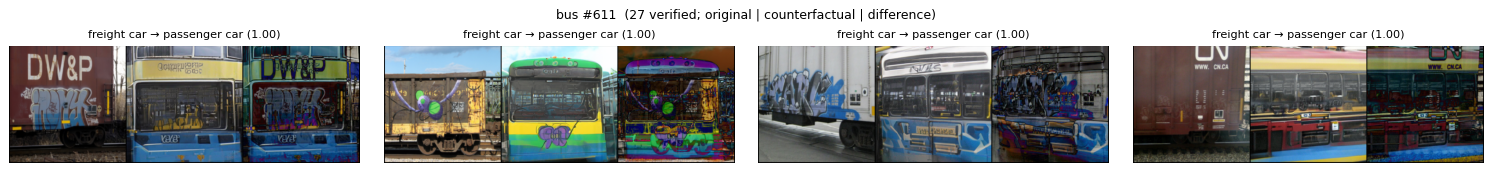

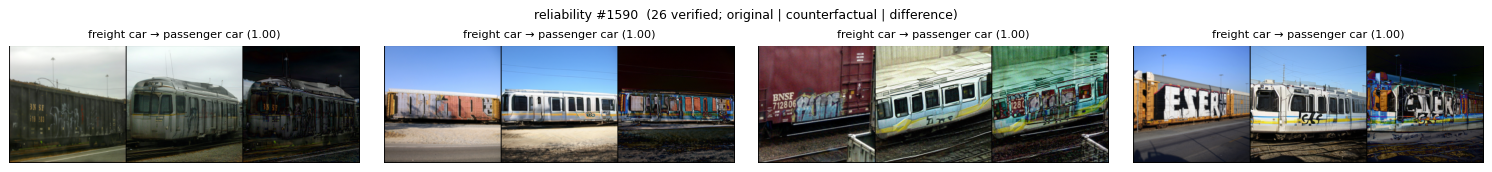

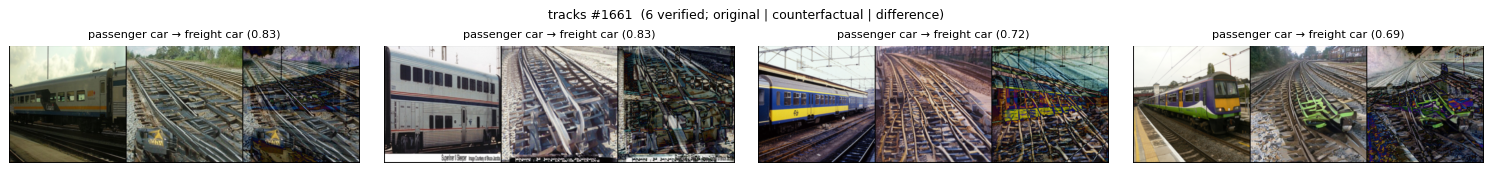

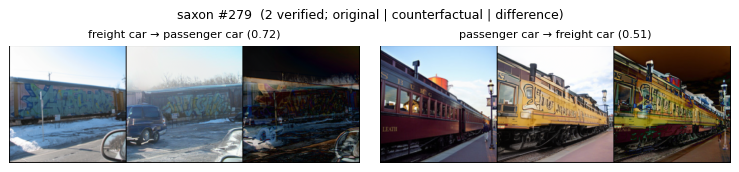

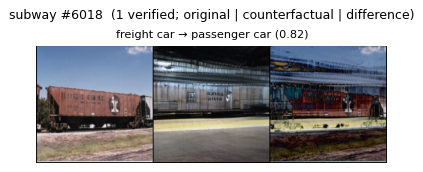

In [8]:
from PIL import Image

def show_pairs(direction_idx, n=4):
    e = index[direction_idx]
    pairs = e["pairs"][:n]
    fig, axes = plt.subplots(1, len(pairs), figsize=(4.2 * len(pairs), 1.9))
    for ax, p in zip(np.atleast_1d(axes), pairs):
        ax.imshow(Image.open(run_dir / "successful_flips" / e["folder"] / p["file"]))
        ax.set_title(f"{CLASS_NAMES[p['orig_class']]} → {CLASS_NAMES[p['target_class']]} "
                     f"({p['confidence']:.2f})", fontsize=9)
        ax.axis("off")
    fig.suptitle(f"{short(e['name'])}  ({e['n_verified']} verified; original | counterfactual | difference)", fontsize=10)
    plt.tight_layout(); show(fig)

for r in results[:5]:
    if r["direction_idx"] in index:
        show_pairs(r["direction_idx"])


## Where next

* **Judge and correct:** notebook 00, steps 7-8, does it for a DINOv3 probe (verdicts per direction,
  then a last-layer refit on the counterfactuals). For an ONNX model PEAL's `onnx2torch` conversion
  provides the trainable module; `get_predictor(ONNX_PATH)` returns it.
* **No code:** the web demo runs exactly this on an uploaded ONNX file and a zip of class folders,
  with a page for the verdicts and the corrected model as a download.
* **Other explainers:** notebook 01 explains a model with SCE counterfactuals instead.
